# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [2]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


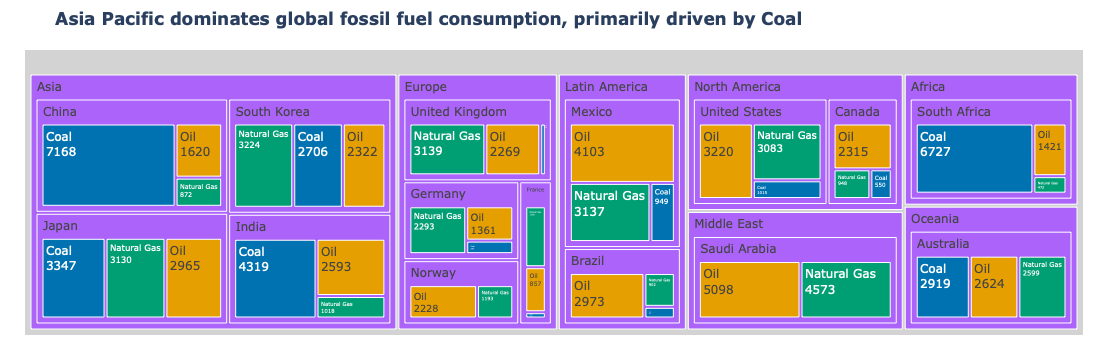

In [3]:
# Task:1 
df_fossil = df.loc[df['Source_Type'] == 'Fossil'].copy()

fig1 = px.treemap(
    df_fossil, 
    path=['Region', 'Country', 'Source'], 
    values='TWh',
    color='Source',
    color_discrete_map={
        'Coal': '#0072B2',        
        'Oil': '#E69F00',         
        'Natural Gas': '#009E73'  
    },
    title="<b>Asia Pacific dominates global fossil fuel consumption, primarily driven by Coal</b>"
)

fig1.update_traces(
    textinfo="label+value",
    marker=dict(pad=dict(t=25)), 
    root_color="lightgrey"
)

fig1.update_layout(margin=dict(t=50, l=25, r=25, b=25))

fig1.show()


## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


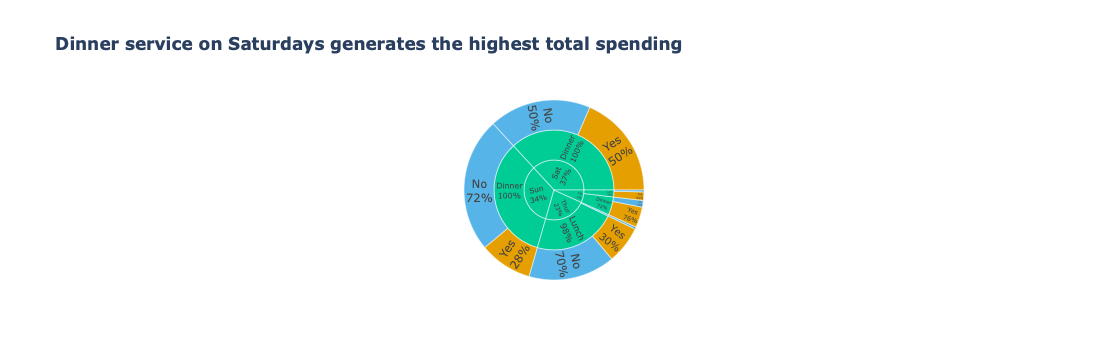

In [4]:
# Task 2
# YOUR CODE HERE
tips = px.data.tips()

tips_agg = tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()

fig2 = px.sunburst(
    tips_agg,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map={
        'Yes': '#E69F00', 
        'No': '#56B4E9'   
    },
    title="<b>Dinner service on Saturdays generates the highest total spending</b>"
)

fig2.update_traces(
    textinfo="label+percent parent",
    insidetextorientation='radial',
    leaf=dict(opacity=1),
    marker=dict(line=dict(color='white', width=0.5))
)

fig2.show()

## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


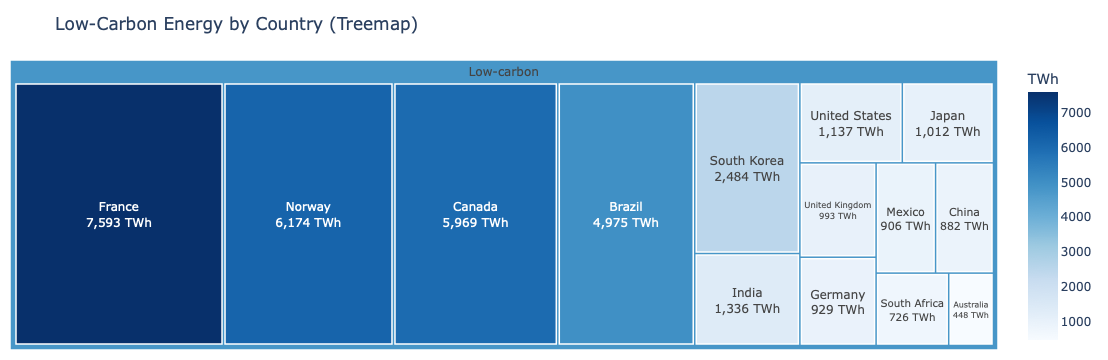

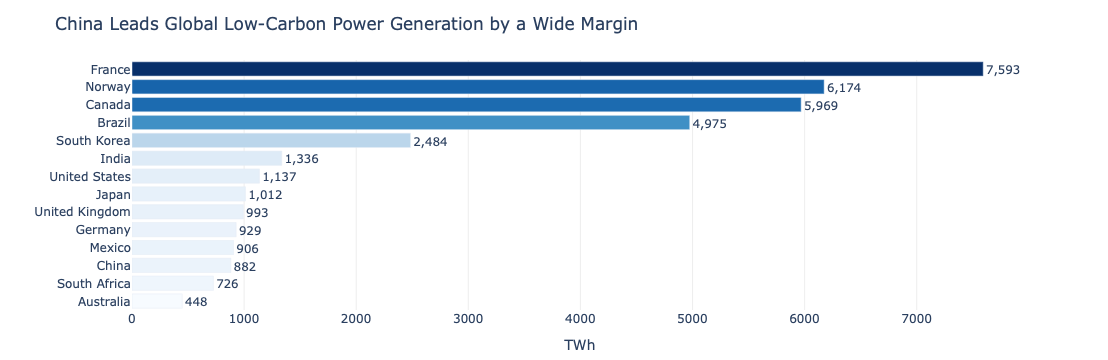

In [5]:
# Task 3 — charts
# YOUR CODE HERE
import plotly.express as px

df_lowcarbon = (
    df.loc[df['Source_Type'] == 'Low-carbon']
    .groupby('Country')['TWh']
    .sum()
    .reset_index()
    .sort_values('TWh', ascending=False)
)
df_lowcarbon['All'] = 'Low-carbon'

# --- Treemap ---
fig3a = px.treemap(
    df_lowcarbon,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale='Blues',
    title='Low-Carbon Energy by Country (Treemap)',
)
fig3a.update_traces(
    texttemplate='%{label}<br>%{value:,.0f} TWh',
    textposition='middle center',
    root_color='#f0f0f0',
    marker=dict(line=dict(width=1.5, color='white')),
)
fig3a.update_layout(
    coloraxis_colorbar=dict(title='TWh'),
    margin=dict(t=60, l=10, r=10, b=10),
)
fig3a.show()

# --- Bar chart ---
df_sorted = df_lowcarbon.sort_values('TWh', ascending=True)

fig3b = px.bar(
    df_sorted,
    x='TWh', y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Blues',
    text='TWh',
    title='China Leads Global Low-Carbon Power Generation by a Wide Margin',
)
fig3b.update_traces(
    texttemplate='%{x:,.0f}',
    textposition='outside',
)
fig3b.update_layout(
    xaxis_title='TWh', yaxis_title='',
    coloraxis_showscale=False,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#eeeeee'),
    margin=dict(t=60, l=10, r=80, b=10),
)
fig3b.show()